In [ ]:
import numpy as np

class EcoDrivingEnv:
    def __init__(self):
        # Topografia expandida: 0 = Downhill, 1 = Flat, 2 = Uphill
        # 200 retas, 40 descidas, 200 retas, 40 subidas
        self.track = [1]*200 + [0]*40 + [1]*200 + [2]*40
        self.track_length = len(self.track)

        self.num_track_states = 3

        # Em vez de 4 ações discretas, temos 1 dimensão de controle contínuo (-1 a 1)
        self.action_dim = 1

        self.max_speed = 120.0

        self.reset()

    def reset(self):
        self.position = 0
        self.speed = 0.0
        self.prev_speed = 0.0  # Guarda a velocidade do passo passado
        self.prev_action = 0.0
        return self.get_state()

    def get_lookahead(self):
        """
        Calcula a distância (em nodos) até a próxima mudança de topografia.
        """
        safe_position = self.position % self.track_length
        current_terrain = self.track[safe_position]

        for i in range(1, self.track_length):
            idx = (safe_position + i) % self.track_length
            if self.track[idx] != current_terrain:
                dist_to_change = i
                next_terrain_type = self.track[idx]
                return dist_to_change, next_terrain_type

        return 0, current_terrain

    def get_state(self):
        # Pega a visão de antecipação
        dist_to_change, next_terrain = self.get_lookahead()
        safe_position = self.position % self.track_length

        return (self.speed, self.track[safe_position], dist_to_change, next_terrain, self.prev_action)

    def step(self, action):
        pedal = float(action[0])
        reward = -3.0  # Pressão constante de tempo
        done = False

        safe_position = self.position % self.track_length
        current_terrain = self.track[safe_position]

        # Identifica se acabamos de ENTRAR em um novo terreno
        prev_terrain = self.track[(self.position - 1) % self.track_length]
        just_entered_downhill = (current_terrain == 0 and prev_terrain == 1)
        just_entered_uphill = (current_terrain == 2 and prev_terrain == 1)

        # CÁLCULO DA FÍSICA E VARIAÇÃO DE VELOCIDADE (Delta V)
        aceleracao_resultante = 0.0

        # Força do Motor / Freio
        if pedal > 0.1:
            aceleracao_resultante += (pedal * 1.0)
        elif pedal < -0.1:
            aceleracao_resultante += (pedal * 20.0) # Pedal é negativo, freia
        else:
            aceleracao_resultante -= 5.0

        # Influência da Gravidade
        if current_terrain == 0:
            aceleracao_resultante += 1.0
        elif current_terrain == 2:
            aceleracao_resultante -= 1.0

        # Aplica a variação e garante os limites do carro
        self.prev_speed = self.speed
        self.speed += aceleracao_resultante
        self.speed = max(0.0, min(120.0, self.speed))

        # Limitada pelos máximos do carro
        delta_v = self.speed - self.prev_speed


        # NOVO SISTEMA DE RECOMPENSA

        if current_terrain == 1: # RETA (Foco na Rampa Pulse & Glide)

            if pedal > 0.1: # Fase de PULSE (Acelerando)
                if self.prev_speed < 120.0:
                    # Quanto mais ele ganha velocidade, mais pontos!
                    # O multiplicador encoraja ele a dar um "tiro" forte para subir a rampa rápido.
                    reward += (delta_v * 100.0)
                else:
                    # Gastar gasolina quando já está no limite aerodinâmico máximo
                    reward -= 50.0 * pedal

            elif -0.1 <= pedal <= 0.1: # Fase de GLIDE (Ponto Morto)
                reward += 200.0
                if self.speed >= 30.0:
                    # Ele está perdendo velocidade (delta_v é negativo), o que poupa gasolina.
                    # Damos um bônus fixo grande por segurar o carro na inércia viável.
                    reward += 100.0

                    # Se ele emendou um glide no outro, ganha bônus (Recompensa a inércia longa)
                    if -0.1 <= self.prev_action <= 0.1:
                        reward += 500.0
                else:
                    # PUNIÇÃO: Deixou a rampa cair demais, o motor quase apagou na reta
                    reward -= 100.0

            elif pedal < -0.1: # Frear na reta (Péssimo, queima inércia)
                reward -= 100.0 * abs(pedal)


        elif current_terrain == 0: # DESCIDA (Foco em aproveitar a gravidade)

            # Chegou devagar na curva para mergulhar?
            if just_entered_downhill:
                if 20.0 <= self.prev_speed <= 60.0:
                    reward += 300.0 # Entrou na velocidade ideal para aproveitar a queda
                elif self.prev_speed > 90.0:
                    reward -= 5000.0 # Entrou voando, acidente fatal
                    done = True

            # Ganhar velocidade de graça
            if -0.1 <= pedal <= 0.1: # Sem usar motor
                if delta_v > 0:
                    # Se a gravidade está dando Delta V positivo, recompense massivamente!
                    reward += (delta_v * 100.0)
            elif pedal > 0.1:
                # Usar motor na descida é desperdício de combustível
                reward -= 300.0 * pedal


        elif current_terrain == 2: # SUBIDA (Foco em atacar a montanha)

            if just_entered_uphill:
                if self.prev_speed >= 100.0:
                    reward += 300.0 # Entrou com tudo, embalo perfeito!
                else:
                    reward -= 500.0 # Entrou devagar, vai sofrer

            # Na subida, deixar a velocidade cair para zero é fatal
            if self.speed <= 5.0:
                reward -= 500.0
                done = True

            # Recompensa por usar força bruta (PULSE) para não deixar a velocidade morrer
            if pedal > 0.1 and self.speed > 40.0:
                reward += 10.0

        self.position += 1

        # FINALIZAÇÃO DO EPISÓDIO
        if self.position >= self.track_length:
            reward += 1000.0 # Bônus por terminar a volta
            done = True

        self.prev_action = pedal
        return self.get_state(), reward, done


# Quick Test
env = EcoDrivingEnv()
print("Environment upgraded for Continuous Action Space (DDPG).")

Environment upgraded for Continuous Action Space (DDPG).


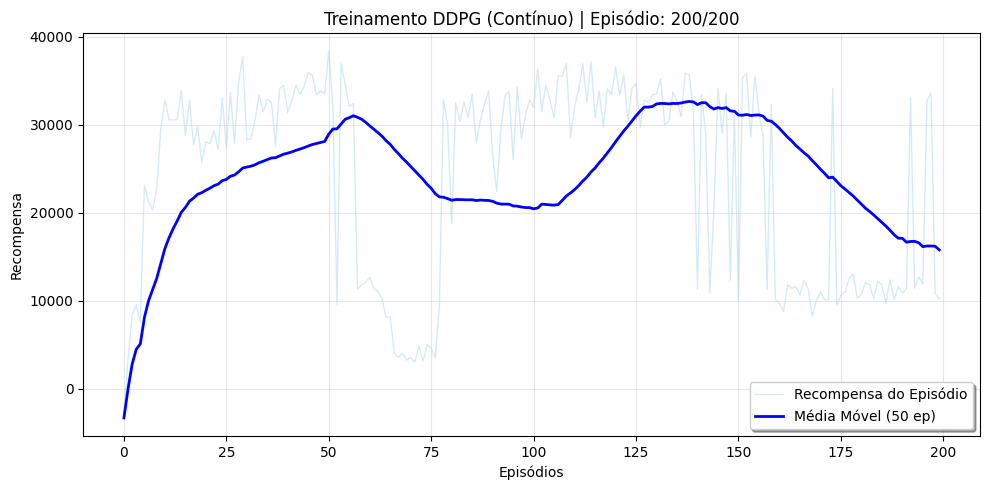


Treinamento DDPG Concluído! Melhor pontuação atingida: 37222.897562261984


In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt
from IPython.display import clear_output
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Iniciando treinamento usando: {device}")

# Tratamento do Estado
def state_to_features(state):
    speed, t_curr, dist_to_change, next_terrain, prev_act = state
    feat = np.zeros(9, dtype=np.float32)
    feat[0] = speed / 120.0
    feat[1 + int(t_curr)] = 1.0
    feat[4] = dist_to_change / 200.0
    feat[5 + int(next_terrain)] = 1.0
    feat[8] = prev_act
    return feat

# Ruído de Exploração para DDPG
class OUNoise:
    def __init__(self, action_dimension, mu=0.0, theta=0.15, sigma=0.2):
        self.action_dimension = action_dimension
        self.mu = mu
        self.theta = theta
        self.sigma = sigma
        self.state = np.ones(self.action_dimension) * self.mu

    def reset(self):
        self.state = np.ones(self.action_dimension) * self.mu

    def sample(self):
        x = self.state
        dx = self.theta * (self.mu - x) + self.sigma * np.random.randn(self.action_dimension)
        self.state = x + dx
        return self.state

# Definição das Redes Neurais
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(Actor, self).__init__()
        self.fc1 = nn.Linear(state_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.out = nn.Linear(128, action_dim)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        return torch.tanh(self.out(x))

class Critic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(Critic, self).__init__()
        self.fc1 = nn.Linear(state_dim + action_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.out = nn.Linear(128, 1)

    def forward(self, state, action):
        x = torch.cat([state, action], dim=1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.out(x)

# Buffer de Experiência
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state_feat, action, reward, next_state_feat, done):
        self.buffer.append((state_feat, action, reward, next_state_feat, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        # Envia os tensores diretamente para a GPU (se houver)
        return (torch.FloatTensor(np.array(states)).to(device),
                torch.FloatTensor(np.array(actions)).to(device),
                torch.FloatTensor(rewards).unsqueeze(1).to(device),
                torch.FloatTensor(np.array(next_states)).to(device),
                torch.FloatTensor(dones).unsqueeze(1).to(device))

    def __len__(self):
        return len(self.buffer)

# Hyperparâmetros
state_dim = 9
action_dim = env.action_dim
batch_size = 128
gamma = 0.99
tau = 0.005
lr_actor = 0.0001
lr_critic = 0.001
episodes = 200

# Enviando as redes para a CPU/GPU
actor = Actor(state_dim, action_dim).to(device)
actor_target = Actor(state_dim, action_dim).to(device)
actor_target.load_state_dict(actor.state_dict())

critic = Critic(state_dim, action_dim).to(device)
critic_target = Critic(state_dim, action_dim).to(device)
critic_target.load_state_dict(critic.state_dict())

actor_optimizer = optim.Adam(actor.parameters(), lr=lr_actor)
critic_optimizer = optim.Adam(critic.parameters(), lr=lr_critic)

memory = ReplayBuffer(100000)
noise = OUNoise(action_dim)

avg_rewards_per_episode = []
smoothed_avg_rewards = []
best_reward = -float('inf')
best_actor_state = None

plt.ion()
plt.figure(figsize=(10, 5))

# Loop de Treinamento
for episode in range(episodes):
    state = env.reset()
    noise.reset()

    state_feat = state_to_features(state)
    state_tensor = torch.FloatTensor(state_feat).unsqueeze(0).to(device)

    total_reward = 0
    done = False

    while not done:
        actor.eval()
        with torch.no_grad():
            action_tensor = actor(state_tensor)
            action_pure = action_tensor.cpu().data.numpy()[0]
        actor.train()

        action = action_pure + noise.sample()
        action = np.clip(action, -1.0, 1.0)

        next_state, reward, done = env.step(action)

        next_state_feat = state_to_features(next_state)
        next_state_tensor = torch.FloatTensor(next_state_feat).unsqueeze(0).to(device)

        memory.push(state_feat, action, reward, next_state_feat, done)

        state = next_state
        state_feat = next_state_feat
        state_tensor = next_state_tensor
        total_reward += reward

        if len(memory) >= batch_size:
            batch_states, batch_actions, batch_rewards, batch_next_states, batch_dones = memory.sample(batch_size)

            # TREINANDO O CRÍTICO
            with torch.no_grad():
                next_actions = actor_target(batch_next_states)
                target_Q = critic_target(batch_next_states, next_actions)
                expected_Q = batch_rewards + (gamma * target_Q * (1 - batch_dones))

            current_Q = critic(batch_states, batch_actions)
            critic_loss = F.mse_loss(current_Q, expected_Q)

            critic_optimizer.zero_grad()
            critic_loss.backward()
            torch.nn.utils.clip_grad_norm_(critic.parameters(), 1.0)
            critic_optimizer.step()

            # TREINANDO O ATOR
            predicted_actions = actor(batch_states)
            actor_loss = -critic(batch_states, predicted_actions).mean()

            actor_optimizer.zero_grad()
            actor_loss.backward()
            torch.nn.utils.clip_grad_norm_(actor.parameters(), 1.0)
            actor_optimizer.step()

            # SOFT UPDATE DAS TARGET NETS
            for target_param, param in zip(actor_target.parameters(), actor.parameters()):
                target_param.data.copy_(target_param.data * (1.0 - tau) + param.data * tau)
            for target_param, param in zip(critic_target.parameters(), critic.parameters()):
                target_param.data.copy_(target_param.data * (1.0 - tau) + param.data * tau)

    avg_rewards_per_episode.append(total_reward)

    if total_reward >= best_reward and episode > episodes // 4:
        best_reward = total_reward
        best_actor_state = actor.state_dict().copy()

    window_size = 50
    smoothed_avg_rewards.append(np.mean(avg_rewards_per_episode[-window_size:]))

    # Sinal de vida para você saber que não travou
    print(f"Episódio {episode+1}/{episodes} finalizado. Recompensa: {total_reward:.1f}")

    # Gráficos (Vai mostrar no episódio 1, e depois a cada 20)
    if (episode + 1) % 20 == 0 or episode == 0 or episode == episodes - 1:
        clear_output(wait=True)

        fig = plt.figure(figsize=(10, 5))

        plt.plot(avg_rewards_per_episode, color='lightblue', alpha=0.5, linewidth=1, label='Recompensa do Episódio')
        if len(smoothed_avg_rewards) > 0:
            plt.plot(smoothed_avg_rewards, color='blue', linewidth=2, label=f'Média Móvel ({window_size} ep)')

        plt.title(f"Treinamento DDPG (Contínuo) | Episódio: {episode+1}/{episodes}")
        plt.xlabel("Episódios")
        plt.ylabel("Recompensa")
        plt.legend(loc='lower right', fancybox=True, shadow=True)
        plt.grid(alpha=0.3)
        plt.tight_layout()

        plt.show()

print(f"\nTreinamento DDPG Concluído! Melhor pontuação atingida: {best_reward}")



```
# This is formatted as code
```

Path map

Capsule


Telemetria da Corrida (Modelo Contínuo)
Passo 001 | Pista: Plano   | Vel Atual:   0.0 km/h -> Ação: Acelerando (+1.00)
Passo 002 | Pista: Plano   | Vel Atual:   1.0 km/h -> Ação: Acelerando (+1.00)
Passo 003 | Pista: Plano   | Vel Atual:   2.0 km/h -> Ação: Acelerando (+1.00)
Passo 004 | Pista: Plano   | Vel Atual:   3.0 km/h -> Ação: Acelerando (+1.00)
Passo 005 | Pista: Plano   | Vel Atual:   4.0 km/h -> Ação: Acelerando (+1.00)
Passo 006 | Pista: Plano   | Vel Atual:   5.0 km/h -> Ação: Acelerando (+1.00)
Passo 007 | Pista: Plano   | Vel Atual:   6.0 km/h -> Ação: Acelerando (+1.00)
Passo 008 | Pista: Plano   | Vel Atual:   7.0 km/h -> Ação: Acelerando (+1.00)
Passo 009 | Pista: Plano   | Vel Atual:   8.0 km/h -> Ação: Acelerando (+1.00)
Passo 010 | Pista: Plano   | Vel Atual:   9.0 km/h -> Ação: Acelerando (+1.00)
Passo 011 | Pista: Plano   | Vel Atual:  10.0 km/h -> Ação: Acelerando (+1.00)
Passo 012 | Pista: Plano   | Vel Atual:  11.0 km/h -> Ação: Acelerando (+1.00)
Passo 013 |

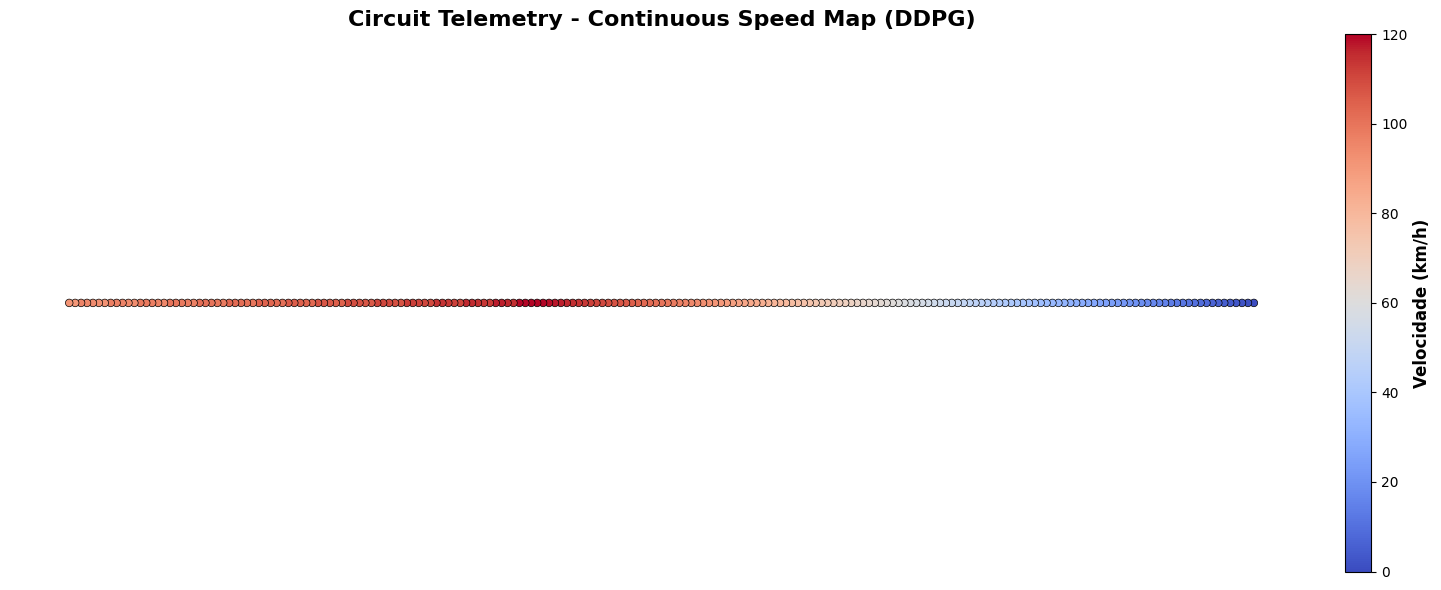

In [ ]:
# Telemetria e Mapeamento do Circuito (DDPG - Ação Contínua)
import matplotlib.pyplot as plt
import numpy as np
import torch

# Carrega a melhor rede do ATOR do DDPG

actor.load_state_dict(best_actor_state)
actor.eval() # Trava a rede em modo de avaliação

print("\nTelemetria da Corrida (Modelo Contínuo)")
state = env.reset()
done = False
lap_reward = 0
step_count = 0

# SYMMETRICAL CAPSULE
def generate_capsule_coords():
    comprimento = 100 # Aumentado para esticar a reta
    raio = 30
    x_c, y_c = [], []

    # Reta Inferior (200 nodes) - Direita para Esquerda
    x_inf = np.linspace(comprimento, 0, 200, endpoint=False)
    for x in x_inf:
        x_c.append(x)
        y_c.append(-raio)

    # Curva Esquerda (40 nodes)
    angles_left = np.linspace(1.5 * np.pi, 0.5 * np.pi, 40, endpoint=False)
    for theta in angles_left:
        x_c.append(0 + raio * np.cos(theta))
        y_c.append(raio * np.sin(theta))

    # Reta Superior (200 nodes) - Esquerda para Direita
    x_sup = np.linspace(0, comprimento, 200, endpoint=False)
    for x in x_sup:
        x_c.append(x)
        y_c.append(raio)

    # Curva Direita (40 nodes)
    angles_right = np.linspace(0.5 * np.pi, -0.5 * np.pi, 40, endpoint=False)
    for theta in angles_right:
        x_c.append(comprimento + raio * np.cos(theta))
        y_c.append(raio * np.sin(theta))

    return x_c, y_c

# Load the 480 coordinates
x_coords, y_coords = generate_capsule_coords()

history_x = []
history_y = []
history_speeds = []
history_pedal = [] # Para armazenar a força do pedal se desejar plotar depois
history_topo = []

# Nomes para log
slope_names = ["Declive", "Plano", "Aclive", "Curva"]

while not done and step_count < env.track_length:
    # Desempacotando o NOVO estado (com Lookahead)
    speed, t_curr, dist_to_change, next_terrain, prev_act = state

    # Passando pelo Ator para gerar a ação contínua
    state_tensor = torch.FloatTensor(state_to_features(state)).unsqueeze(0)
    with torch.no_grad():
        # O Ator retorna um tensor com o valor do pedal. Extraímos o numpy array
        action = actor(state_tensor).cpu().data.numpy()[0]

    # Executa a ação
    next_state, reward, done = env.step(action)

    current_terrain_val = env.track[env.position-1]
    current_terrain_name = slope_names[current_terrain_val]

    # Formata a leitura do pedal para o console de telemetria
    pedal_val = float(action[0])
    if pedal_val > 0.1:
        pedal_str = f"Acelerando ({pedal_val:+.2f})"
    elif pedal_val < -0.1:
        pedal_str = f"Freando    ({pedal_val:+.2f})"
    else:
        pedal_str = f"Glide      ({pedal_val:+.2f})"

    # Print formatado para velocidade e atuação contínua
    print(f"Passo {step_count+1:03d} | Pista: {current_terrain_name:<7} | Vel Atual: {speed:5.1f} km/h -> Ação: {pedal_str}")

    history_x.append(x_coords[step_count])
    history_y.append(y_coords[step_count])
    history_speeds.append(speed)
    history_pedal.append(pedal_val)
    history_topo.append(current_terrain_val)

    state = next_state
    lap_reward += reward
    step_count += 1

print(f"\nPontuação Final da Corrida: {lap_reward:.1f} pontos")

# Desenhando o Mapa (Matplotlib)
plt.figure(figsize=(16, 6))

# Connect the nodes with a racing line
plot_x = list(history_x) + [history_x[0]]
plot_y = list(history_y) + [history_y[0]]
plt.plot(plot_x, plot_y, color='lightgray', linestyle='-', linewidth=2, zorder=1)

#(coolwarm: Azul -> Frio/Devagar, Vermelho -> Quente/Rápido)
scatter = plt.scatter(history_x, history_y, c=history_speeds, cmap='coolwarm',
                      s=30, zorder=2, edgecolors='black', linewidths=0.5, vmin=0, vmax=120)

# Adiciona a barra de cores indicando a velocidade
cbar = plt.colorbar(scatter, pad=0.02)
cbar.set_label('Velocidade (km/h)', fontsize=12, fontweight='bold')

plt.title("Circuit Telemetry - Continuous Speed Map (DDPG)", fontsize=16, fontweight='bold')
plt.axis('equal')
plt.axis('off')

import matplotlib.lines as mlines

plt.tight_layout()
plt.show()

Teste ----------------------------------------